# Step 2 — Explore DroneAudioset

**Why this notebook exists before any training code:**  
Every assumption we have about the dataset — label names, sample rate, clip length, class balance — must be verified here. Bugs caught at exploration cost nothing. The same bug caught after training a model for 2 hours costs 2 hours plus the confusion of debugging through model weights.

**What we are answering in this notebook:**
1. What does the dataset structure look like across its three relevant configs?
2. How balanced are the classes? (affects whether we need class weights at training time)
3. Is the sample rate already 16 kHz, or do we need to resample?
4. Do the audio clips actually sound like drones?
5. Do drone spectrograms show the harmonic bands we expect — and do non-drone spectrograms look different?

Checkpoint at the end: if all five questions have good answers, we proceed to Step 3 (preprocessing pipeline). If not, we fix the problem here.

**Prerequisites — do these once in the terminal before launching Jupyter:**

```powershell
.venv\Scripts\Activate.ps1
huggingface-cli login        # prompts for token, stores it permanently — never needed again
jupyter notebook
```

Also set `HF_HUB_DISABLE_SYMLINKS_WARNING=1` permanently: Start → search "environment variables" → Edit environment variables for your account → New. Suppresses a harmless Windows symlinks warning on every HuggingFace call.

## Imports

- **numpy** — numerical arrays; audio is a float32 array under the hood
- **matplotlib / librosa.display** — plotting spectrograms
- **librosa** — audio feature extraction (mel spectrogram, MFCC); also handles resampling
- **datasets** — HuggingFace library for downloading and streaming DroneAudioset
- **IPython.display.Audio** — plays audio inline in Jupyter so we can actually listen
- **pandas** — convenient for counting and displaying label distributions

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
from datasets import load_dataset, concatenate_datasets
from IPython.display import Audio, display

print('All imports OK')

All imports OK


## 1. Dataset structure — three configs

DroneAudioset is split into four named configs. We use three of them:

| Config | Contents | Role in training |
|---|---|---|
| `drone-with-source` | Drone audio mixed with real background sounds | **Positive examples** — most realistic; what the model will face in deployment |
| `drone-only` | Isolated drone audio, no background | **Positive examples** — teaches the pure acoustic signature; helps at close range where drone dominates |
| `source-only` | Background sounds, no drone present | **Negative examples** — wind, traffic, birds, silence |
| `ground-truth` | Clean reference recordings | Skipped — not useful for training a detector |

**Why there is no label field in the raw data:** each config is already a single class by construction. A clip in `drone-with-source` is always a drone clip; a clip in `source-only` is always a non-drone clip. We assign the binary label (`is_drone`) ourselves based on which config each clip came from.

We use streaming to inspect the schema of one config without downloading anything, then download a small subset of all three for interactive exploration.

In [2]:
# Stream one sample from drone-with-source to inspect the field structure
# The dataset uses numbered splits (train_001, train_002, ...) instead of a single 'train'
ds_stream = load_dataset('ahlab-drone-project/DroneAudioSet', 'drone-only', streaming=True, split='train_001')
sample = next(iter(ds_stream))

print('Field names:', list(sample.keys()))
print()
for k, v in sample.items():
    if isinstance(v, dict):
        print(f'  {k}: dict with keys {list(v.keys())}')
    elif isinstance(v, (list, np.ndarray)):
        arr = np.array(v)
        print(f'  {k}: array shape={arr.shape} dtype={arr.dtype}')
    else:
        print(f'  {k}: {type(v).__name__} = {repr(v)}')

Field names: ['file_path', 'audio', 'data_type']

  file_path: str = 'drone-only-recordings/drone2-only/mic-dist-50cm/throttle-low/mic2_8array-down-File3.wav'
  audio: dict with keys ['array', 'sampling_rate', 'path']
  data_type: str = 'drone-only'


In [3]:
import soundfile as sf
import io

def play_clip(audio):
    arr = np.array(audio['array'], dtype=np.float32)
    if arr.ndim > 1:
        arr = arr[:, 0]          # 8-mic array — take mic 0 for playback
    max_val = np.abs(arr).max()
    if max_val > 0:
        arr = arr / max_val
    buf = io.BytesIO()
    sf.write(buf, arr, audio['sampling_rate'], format='WAV', subtype='PCM_16')
    buf.seek(0)
    display(Audio(data=buf.read()))

print('play_clip() defined OK')

play_clip() defined OK


In [31]:
# Verify play_clip works and inspect one clip's shape/dtype before loading the full subset.
# This streams only 1 clip — fast, no memory impact.
verify_stream = load_dataset('ahlab-drone-project/DroneAudioSet', 'drone-only',
                             streaming=True, split='train_008')
item = next(iter(verify_stream))
arr_raw = np.array(item['audio']['array'])
sr = item['audio']['sampling_rate']
print(f'file_path : {item["file_path"]}')
print(f'shape     : {arr_raw.shape}  (samples x channels)')
print(f'dtype     : {arr_raw.dtype}')
print(f'sr        : {sr} Hz')
print(f'duration  : {arr_raw.shape[0] / sr:.1f} s')
print(f'RAM/clip  : ~{arr_raw.nbytes / 1e6:.0f} MB raw  (x2 with Arrow overhead)')
print()
print('Playing mic 0 of this clip:')
play_clip(item['audio'])

file_path : drone-only-recordings/drone2-only/mic-dist-25cm/throttle-low/mic2_8array-down-File3.wav
shape     : (1451819, 8)  (samples x channels)
dtype     : float64
sr        : 16000 Hz
duration  : 90.7 s
RAM/clip  : ~93 MB raw  (x2 with Arrow overhead)

Playing mic 0 of this clip:


## 2. Download a subset for exploration

**Why streaming instead of `load_dataset` directly:**
`load_dataset` without `streaming=True` downloads ALL parquet files for the entire config before
returning anything. For `drone-with-source` that is 252 splits — even if you write `split='train_001[:70]'`,
it still fetches everything. The `[:70]` slice only controls what gets returned to Python after the
full download is complete.

Using `streaming=True` + iterating until we have enough clips downloads only those splits, then stops.
Each split has ~18 clips (6 background files × 3 mic types), so 70 clips ≈ 4 splits downloaded.

**Labels are assigned by us.** Each config is a single class by construction, so we add `is_drone` after
loading. The result is a plain Python list of dicts — simple, no Dataset API needed for exploration.

In [5]:
import random

AUDIO_FIELD = 'audio'
LABEL_FIELD = 'is_drone'
DRONE_LABEL = 1
NON_DRONE_LABEL = 0

# 15 clips per config: enough to listen to 5, plot 3 spectrograms, check durations.
# Each raw clip ≈ 89 MB (8-channel, 91 s, float64) → 15 × 3 configs ≈ 4 GB raw.
N_EXPLORE = 5

def load_clips_streaming(config, label, n=N_EXPLORE):
    """Stream splits one at a time and stop as soon as n clips are collected."""
    clips = []
    split_idx = 1
    while len(clips) < n:
        split_name = f'train_{split_idx:03d}'
        try:
            stream = load_dataset('ahlab-drone-project/DroneAudioSet', config,
                                  streaming=True, split=split_name)
            before = len(clips)
            for item in stream:
                item[LABEL_FIELD] = label
                clips.append(item)
                if len(clips) >= n:
                    break
            print(f'  {split_name}: +{len(clips) - before} clips  (total {len(clips)}/{n})')
        except Exception as e:
            print(f'  Stopped at {split_name}: {e}')
            break
        split_idx += 1
    return clips

print('Constants and load_clips_streaming() defined OK')

Constants and load_clips_streaming() defined OK


In [6]:
print('Loading drone-with-source (positive — drone + background noise)...')
mixed_clips = load_clips_streaming('drone-with-source', DRONE_LABEL)
print(f'Done: {len(mixed_clips)} clips')

Loading drone-with-source (positive — drone + background noise)...
  train_001: +5 clips  (total 5/5)
Done: 5 clips


In [7]:
print('Loading drone-only (positive — isolated drone, no background)...')
clean_clips = load_clips_streaming('drone-only', DRONE_LABEL)
print(f'Done: {len(clean_clips)} clips')

Loading drone-only (positive — isolated drone, no background)...
  train_001: +5 clips  (total 5/5)
Done: 5 clips


In [8]:
print('Loading source-only (negative — background noise, no drone)...')
bg_clips = load_clips_streaming('source-only', NON_DRONE_LABEL)
print(f'Done: {len(bg_clips)} clips')

Loading source-only (negative — background noise, no drone)...
  train_001: +5 clips  (total 5/5)
Done: 5 clips


In [9]:
ds = mixed_clips + clean_clips + bg_clips
random.seed(42)
random.shuffle(ds)

drone_clips     = [item for item in ds if item[LABEL_FIELD] == DRONE_LABEL]
non_drone_clips = [item for item in ds if item[LABEL_FIELD] == NON_DRONE_LABEL]

print(f'Total clips : {len(ds)}')
print(f'  Drone     : {len(drone_clips)}  (mixed + clean)')
print(f'  Non-drone : {len(non_drone_clips)}  (background only)')

Total clips : 15
  Drone     : 10  (mixed + clean)
  Non-drone : 5  (background only)


## 3. Label distribution

**Why this matters for training:**  
A binary classifier trained on imbalanced data learns a shortcut: always predict the majority class. If 80% of clips are non-drone, predicting "no drone" every time achieves 80% accuracy while being completely useless. We need to know the imbalance ratio now so we can pass `class_weight` to the model or adjust how many clips we draw from each config.

In this exploration subset we loaded equal numbers from each config (70 each), giving a roughly 2:1 drone-to-background ratio. The full dataset may have a different natural ratio — we will check that in Step 3.

In [10]:
labels = [item[LABEL_FIELD] for item in ds]
label_counts = pd.Series(labels).value_counts().rename(
    index={DRONE_LABEL: 'drone', NON_DRONE_LABEL: 'non-drone'})

print('Label counts:')
print(label_counts.to_string())
print()
ratio = label_counts.max() / label_counts.min()
print(f'Imbalance ratio: {ratio:.1f}:1  ', end='')
if ratio > 3:
    print('⚠ use class_weight in training')
else:
    print('✓ balanced enough for unweighted training')

Label counts:
drone        10
non-drone     5

Imbalance ratio: 2.0:1  ✓ balanced enough for unweighted training


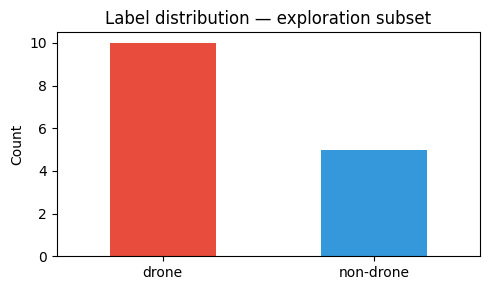

In [11]:
fig, ax = plt.subplots(figsize=(5, 3))
label_counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'])
ax.set_title('Label distribution — exploration subset')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Sample rate check

**Why 16 kHz is required:**  
YAMNet (the model we fine-tune in Step 4) was trained on 16 kHz audio. Passing a different sample rate produces a frequency mismatch — the model's learned frequency representations no longer align with the input. The result is degraded accuracy that is hard to debug because the model still runs and produces numbers.

Also: drone blade harmonics live below 1 kHz, and the Nyquist theorem says a 16 kHz sample rate captures everything up to 8 kHz — more than enough. Storing at higher rates adds size and processing time with no benefit for this task.

If the dataset is not at 16 kHz, the preprocessing pipeline (Step 3) will resample with `librosa.resample`. We just need to know now so we plan for it.

In [12]:
print('Checking sample rates across first 10 clips...')
sample_rates = set()
for i, item in enumerate(ds[:10]):
    audio = item[AUDIO_FIELD]
    sr = audio['sampling_rate']
    duration = len(audio['array']) / sr
    sample_rates.add(sr)
    label_str = 'drone' if item[LABEL_FIELD] == DRONE_LABEL else 'non-drone'
    print(f'  clip {i:02d} [{label_str}]: sr={sr} Hz, duration={duration:.2f}s')

print()
if sample_rates == {16000}:
    print('✓ All clips are 16 kHz — no resampling needed in the pipeline')
else:
    print(f'⚠ Sample rates found: {sample_rates}')
    print('  → Add librosa.resample(..., target_sr=16000) to the preprocessing pipeline')

Checking sample rates across first 10 clips...
  clip 00 [drone]: sr=16000 Hz, duration=151.74s
  clip 01 [non-drone]: sr=16000 Hz, duration=152.00s
  clip 02 [drone]: sr=16000 Hz, duration=30.74s
  clip 03 [drone]: sr=16000 Hz, duration=91.00s
  clip 04 [non-drone]: sr=16000 Hz, duration=31.00s
  clip 05 [non-drone]: sr=16000 Hz, duration=30.83s
  clip 06 [drone]: sr=16000 Hz, duration=90.74s
  clip 07 [drone]: sr=16000 Hz, duration=30.78s
  clip 08 [drone]: sr=16000 Hz, duration=31.00s
  clip 09 [drone]: sr=16000 Hz, duration=152.00s

✓ All clips are 16 kHz — no resampling needed in the pipeline


## 5. Listen to drone clips

**Why listening matters:**  
Spectrograms can look plausible even when the audio is wrong — a mislabeled clip, a recording at the wrong gain, or a corrupted file can produce a spectrogram that looks vaguely like the target class. Human ears are much better at catching this. Listening to 5 clips takes 30 seconds and has caught real issues in published datasets.

**What a drone should sound like:** a continuous mechanical hum, often described as "warbling." The fundamental frequency is the blade pass frequency — for a typical consumer quadcopter this is around 100–200 Hz, which you can hear as a low buzz. Above it are harmonics (200 Hz, 300 Hz, ...) giving it a tonal character.

In [ ]:
print(f'Playing {min(5, len(drone_clips))} drone clips:')
for i, clip in enumerate(drone_clips[:5]):
    audio = clip[AUDIO_FIELD]
    print(f'  Drone clip {i+1} — {len(audio["array"])/audio["sampling_rate"]:.2f}s at {audio["sampling_rate"]} Hz')
    play_clip(audio)
    print()

## 6. Listen to non-drone clips

**What to listen for:** these should sound clearly different from drones — wind, traffic, birds, silence, human voices. If any non-drone clip sounds like a drone, it is either mislabeled or a hard negative (helicopter, insect) that may cause problems during training. Note any such clips.

In [ ]:
print(f'Playing {min(5, len(non_drone_clips))} non-drone clips:')
for i, clip in enumerate(non_drone_clips[:5]):
    audio = clip[AUDIO_FIELD]
    print(f'  Non-drone clip {i+1} — {len(audio["array"])/audio["sampling_rate"]:.2f}s at {audio["sampling_rate"]} Hz')
    play_clip(audio)
    print()

## 6b. mic-dist comparison — what does that variable actually mean?

The dataset paths contain `mic-dist-25cm` and `mic-dist-50cm`. Two hypotheses:

- **Hypothesis A — drone-to-mic distance:** the drone was 25 cm or 50 cm from the array. If true,
  the 25 cm clip should sound dramatically louder (inverse square law: half the distance = 4× the power).
- **Hypothesis B — mic array element spacing:** the physical distance between the capsules in the
  8-element array. This controls the array's angular resolution for beamforming. If true, both clips
  should sound like the same drone at the same volume — only the directional sensitivity of the array
  differs, which is inaudible when playing back mic 0 alone.

The two clips below are identical in every other variable: same room, drone model, throttle, speaker
loudness, speaker distance, mic type (mic2\_8array-down), and background (silence — no playback audio).
Listen and judge.

In [ ]:
# Search through splits to find one silence+mic2_8array-down clip for each mic distance.
# train_001 is known to have 50cm; 25cm split number is unknown, so we scan until found.
DISTANCES = ['mic-dist-50cm', 'mic-dist-25cm']
PATH_FILTERS = ['silence', 'mic2_8array-down']

def find_clip_by_path(config, path_filters, max_splits=30):
    for split_idx in range(1, max_splits + 1):
        split_name = f'train_{split_idx:03d}'
        try:
            stream = load_dataset('ahlab-drone-project/DroneAudioSet', config,
                                  streaming=True, split=split_name)
            for item in stream:
                if all(f in item['file_path'] for f in path_filters):
                    return item, split_name
        except Exception:
            break
    return None, None

for dist in DISTANCES:
    filters = PATH_FILTERS + [dist]
    item, found_split = find_clip_by_path('drone-with-source', filters)
    if item is None:
        print(f'{dist}: no matching clip found in first 30 splits')
    else:
        print(f'{dist}  (found in {found_split}):')
        print(f'  {item["file_path"]}')
        play_clip(item['audio'])
        print()

## 7. Mel spectrogram comparison

**What a mel spectrogram is:**  
A mel spectrogram is a 2D image of sound: time on the x-axis, frequency on the y-axis (scaled to the mel scale, which compresses high frequencies the way human hearing does), and brightness showing loudness in decibels. It is computed by applying a Short-Time Fourier Transform (STFT) to overlapping frames of audio and rescaling the frequency axis.

**Why mel and not linear frequency scale:**  
The mel scale concentrates resolution in the low-frequency range where drone harmonics live (below 1 kHz). A linear scale would spread the 128 frequency bins across 0–8 kHz, leaving very few bins for the important 50–1000 Hz range.

**What to look for in drone clips:**  
- Horizontal bright bands below 1 kHz — these are the blade pass frequency (BPF) and its harmonics
- The bands should be roughly evenly spaced in frequency (harmonics are integer multiples of the BPF)
- They should persist across the full time axis (drones produce a sustained signal)

**What non-drone clips should look like:**  
- Diffuse, unstructured energy — wind noise spreads across all frequencies
- Or structured but not harmonic — traffic has engine noise but at different frequencies and irregular patterns
- No clear horizontal bands in the 50–1000 Hz region

**If both look the same:** the preprocessing has a bug. Do not proceed to training.

In [13]:
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
TARGET_SR = 16000

def plot_mel(ax, clip, title):
    audio = clip[AUDIO_FIELD]
    y = np.array(audio['array'], dtype=np.float32)
    if y.ndim > 1:
        y = y[:, 0]             # take mic 0 from 8-channel array
    sr = audio['sampling_rate']
    if sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
        sr = TARGET_SR
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT,
                                        hop_length=HOP_LENGTH, n_mels=N_MELS)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title, fontsize=9)
    return img

print('plot_mel() defined OK')

plot_mel() defined OK


Drone 1 spectrogram OK — mic3_8array-up-File1.wav
Drone 2 spectrogram OK — mic2_8array-down-silence.wav
Drone 3 spectrogram OK — mic1_soundskrit-File3.wav
Non-drone 1 spectrogram OK — mic3_8array-up-File1.wav
Non-drone 2 spectrogram OK — mic1_soundskrit-silence.wav
Non-drone 3 spectrogram OK — mic2_8array-down-silence.wav


C:\Users\RKei\AppData\Local\Temp\ipykernel_24612\1016878758.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


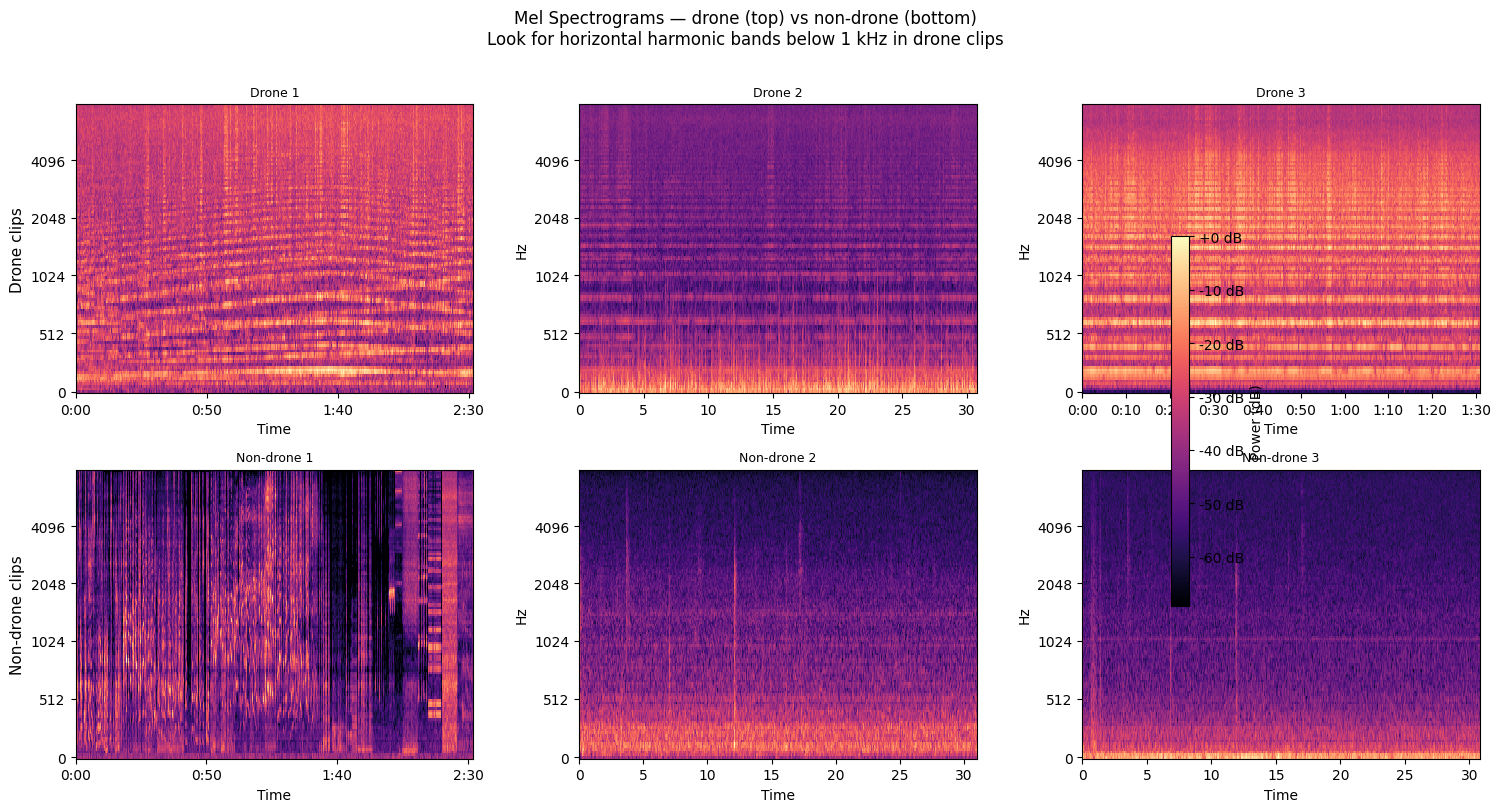

In [14]:
n_cols = 3
fig, axes = plt.subplots(2, n_cols, figsize=(15, 8))

for i in range(n_cols):
    img = plot_mel(axes[0, i], drone_clips[i], f'Drone {i+1}')
    print(f'Drone {i+1} spectrogram OK — {drone_clips[i]["file_path"].split("/")[-1]}')

for i in range(n_cols):
    img = plot_mel(axes[1, i], non_drone_clips[i], f'Non-drone {i+1}')
    print(f'Non-drone {i+1} spectrogram OK — {non_drone_clips[i]["file_path"].split("/")[-1]}')

axes[0, 0].set_ylabel('Drone clips', fontsize=11)
axes[1, 0].set_ylabel('Non-drone clips', fontsize=11)
plt.colorbar(img, ax=axes, format='%+2.0f dB', shrink=0.6, label='Power (dB)')
plt.suptitle('Mel Spectrograms — drone (top) vs non-drone (bottom)\n'
             'Look for horizontal harmonic bands below 1 kHz in drone clips', y=1.01)
plt.tight_layout()
plt.show()

## 7b. MFCC, delta-MFCC, and concatenated feature matrix

MFCCs compress the mel spectrogram into ~13 numbers per time frame — coefficient 1 is overall energy, the rest capture spectral shape. The **delta** is the frame-to-frame first derivative: it captures how fast the spectrum is changing over time. Stacking `[MFCC ; delta]` doubles the feature height and gives the model both shape and motion.

- **Drone clips:** MFCCs should be stable (flat horizontal bands), deltas near-zero and smooth
- **Non-drone clips:** MFCCs vary more across time, deltas are larger and noisier

In [23]:
N_MFCC = 13

def compute_mfcc_features(clip):
    audio = clip[AUDIO_FIELD]
    y = np.array(audio['array'], dtype=np.float32)
    if y.ndim > 1:
        y = y[:, 0]
    sr = audio['sampling_rate']
    if sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
    mfcc  = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=N_MFCC,
                                  n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta = librosa.feature.delta(mfcc)
    return mfcc, delta, np.vstack([mfcc, delta])

drone_mfcc,     drone_delta,     drone_concat     = compute_mfcc_features(drone_clips[2])
nondrone_mfcc,  nondrone_delta,  nondrone_concat  = compute_mfcc_features(non_drone_clips[2])
print('Features computed OK')

Features computed OK


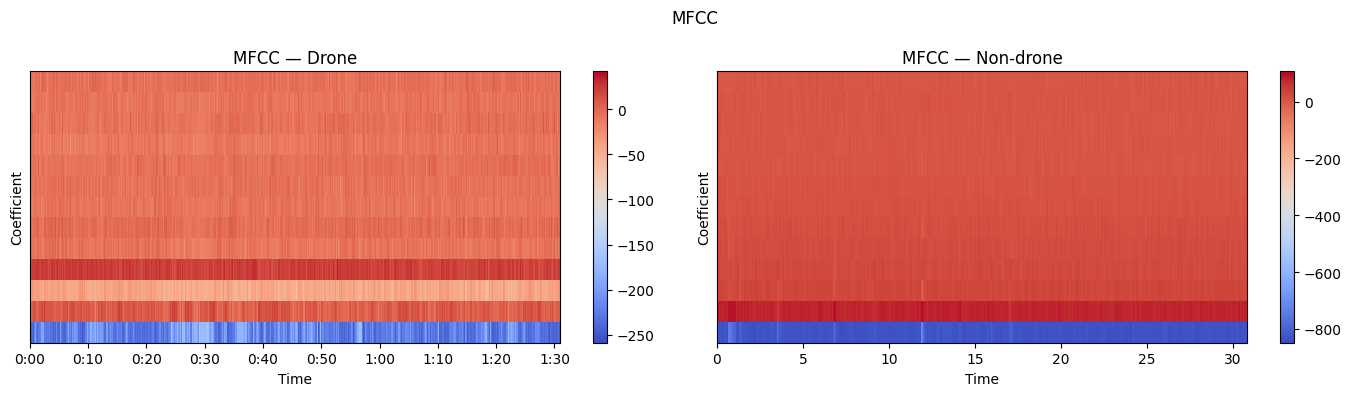

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, feat, title in zip(axes,
                            [drone_mfcc, nondrone_mfcc],
                            ['MFCC — Drone', 'MFCC — Non-drone']):
    img = librosa.display.specshow(feat, sr=TARGET_SR, hop_length=HOP_LENGTH,
                                   x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(title)
    ax.set_ylabel('Coefficient')
    plt.colorbar(img, ax=ax)
plt.suptitle('MFCC')
plt.tight_layout()
plt.show()

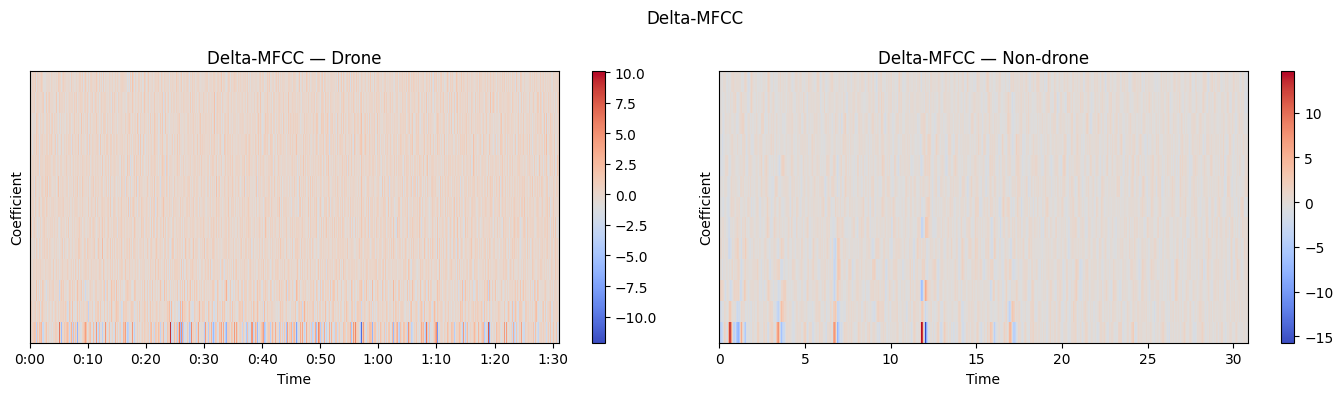

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, feat, title in zip(axes,
                            [drone_delta, nondrone_delta],
                            ['Delta-MFCC — Drone', 'Delta-MFCC — Non-drone']):
    img = librosa.display.specshow(feat, sr=TARGET_SR, hop_length=HOP_LENGTH,
                                   x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(title)
    ax.set_ylabel('Coefficient')
    plt.colorbar(img, ax=ax)
plt.suptitle('Delta-MFCC')
plt.tight_layout()
plt.show()

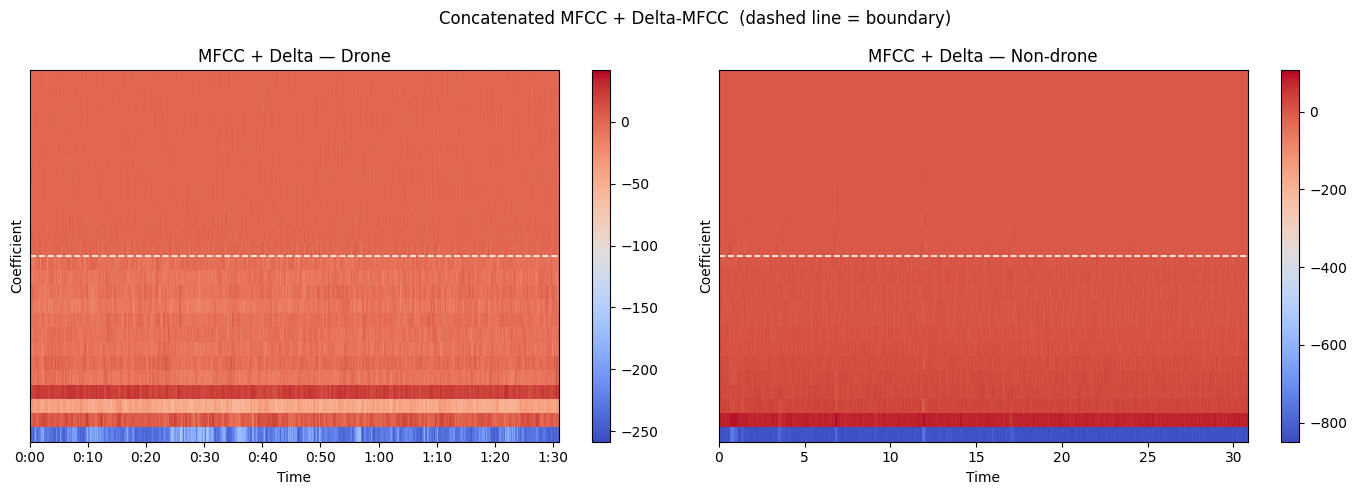

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat, title in zip(axes,
                            [drone_concat, nondrone_concat],
                            ['MFCC + Delta — Drone', 'MFCC + Delta — Non-drone']):
    img = librosa.display.specshow(feat, sr=TARGET_SR, hop_length=HOP_LENGTH,
                                   x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(title)
    ax.set_ylabel('Coefficient')
    ax.axhline(y=N_MFCC - 0.5, color='white', linewidth=1.2, linestyle='--')
    plt.colorbar(img, ax=ax)
plt.suptitle('Concatenated MFCC + Delta-MFCC  (dashed line = boundary)')
plt.tight_layout()
plt.show()

## 8. Clip duration distribution

**Why this matters:**  
The preprocessing pipeline (Step 3) segments each clip into 1-second windows. If clips are shorter than 1 second they will produce zero usable windows and be silently dropped. We need to know the duration distribution to understand how much usable data we actually have.

In [ ]:
durations = []
for item in ds:
    audio = item[AUDIO_FIELD]
    sr = audio['sampling_rate']
    durations.append(len(audio['array']) / sr)

durations = np.array(durations)
print('Duration stats (seconds):')
print(f'  min={durations.min():.2f}  max={durations.max():.2f}  mean={durations.mean():.2f}  median={np.median(durations):.2f}')
print(f'  Clips shorter than 1 s (dropped by pipeline): {(durations < 1.0).sum()}')

plt.figure(figsize=(8, 3))
plt.hist(durations, bins=30, color='steelblue', edgecolor='white')
plt.axvline(1.0, color='red', linestyle='--', label='1 s window minimum')
plt.xlabel('Duration (s)')
plt.ylabel('Count')
plt.title('Clip duration distribution (210-clip subset)')
plt.legend()
plt.tight_layout()
plt.show()

## Checkpoint

Work through this list before proceeding to Step 3 (preprocessing pipeline).

| # | Question | Answer | Pass? |
|---|---|---|---|
| 1 | What fields does each config have beyond `audio`? | *(note any metadata fields)* | |
| 2 | What is the sample rate? | *(16000 Hz = no resampling needed)* | |
| 3 | Do drone clips sound like drones? | *(yes / no / uncertain)* | |
| 4 | Do non-drone clips sound clearly different? | *(yes / no)* | |
| 5 | Do drone spectrograms show horizontal bands below 1 kHz? | *(yes / no)* | |
| 6 | Do non-drone spectrograms look clearly different? | *(yes / no)* | |
| 7 | How many clips are shorter than 1 s? | *(count)* | |

**All yes → proceed to Step 3.**  
**Spectrograms look the same → do not proceed.** Check: is audio loaded as float32? Is `y_axis='mel'` correct? Are drone and non-drone clip lists populated?

---
*Commit this notebook without outputs: `Kernel → Restart & Clear Output` before committing. Output cells contain binary audio data that bloats the git history.*